In [2]:
# import things
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from lo_tools import Lfun

import sys
from pathlib import Path

Ldir = Lfun.Lstart()

In [69]:
# read in model data for each station
station_names = ["SAR003", "PSS019", "SKG003","HCB004", "HCB003", "ADM003", "CMB003", "GOR001", "CSE001", "EAP001", "SIN001", "PSB003"]

data_lo = {}
data_ssc = {}

for station in station_names:
    filename_lo = f"{station}_2014.01.01_2014.12.31.nc"
    filename_ssc = f"{station}_2014.01.01_2014.12.31_ssc.nc"
    filepath_lo = "./stations/" + filename_lo
    filepath_ssc = "./stations/" + filename_ssc

    data_lo[station] = xr.open_dataset(filepath_lo)
    data_ssc[station] = xr.open_dataset(filepath_ssc)

In [70]:
data_ssm = {}
data_ssm["ADM003"] = xr.open_dataset(Ldir['LOo']/ 'stations'/ "ADM003_2014.01.01_2014.12.31_ssm.nc")
data_ssm["SAR003"] = xr.open_dataset(Ldir['LOo']/ 'stations'/ "SAR003_2014.01.01_2014.12.31_ssm.nc")

In [71]:
print(data_ssm["ADM003"].data_vars)
#print(data_lo["ADM003"].data_vars)

Data variables:
    salinity     (time, siglay) float32 15kB ...
    temp         (time, siglay) float32 15kB ...
    CCHL1        (time, siglay) float32 15kB ...
    DOXG         (time, siglay) float32 15kB ...
    NH4          (time, siglay) float32 15kB ...
    NO3          (time, siglay) float32 15kB ...
    PO4          (time, siglay) float32 15kB ...
    TDIC         (time, siglay) float32 15kB ...
    TALK         (time, siglay) float32 15kB ...
    pH           (time, siglay) float32 15kB ...
    pCO2         (time, siglay) float32 15kB ...
    zeta         (time) float32 1kB ...
    depth        (time) float32 1kB ...
    sigma_depth  (time, siglay) float32 15kB ...
    x            float32 4B ...
    y            float32 4B ...
    lon          float64 8B ...
    lat          float64 8B ...
    h            float64 8B ...


In [72]:
# read in observational data for each station
data_obs = pd.read_pickle( Ldir['LOo'] / 'obsmod'/ 'combined_bottle_2014_cas7_t1_x11ab_ssc_ssmpnnl.pkl')
data_obs = data_obs["obs"]

# ensure datatime format 
data_obs["time"] = pd.to_datetime(data_obs["time"])


In [73]:
ssm_depths = ds_ssm["sigma_depth"].mean(dim="time").values
print(ssm_depths)

[ 1.4797798  5.6652265 11.874611  19.527395  28.382673  38.29266
 49.154152  60.889484  73.437614  86.74882  ]


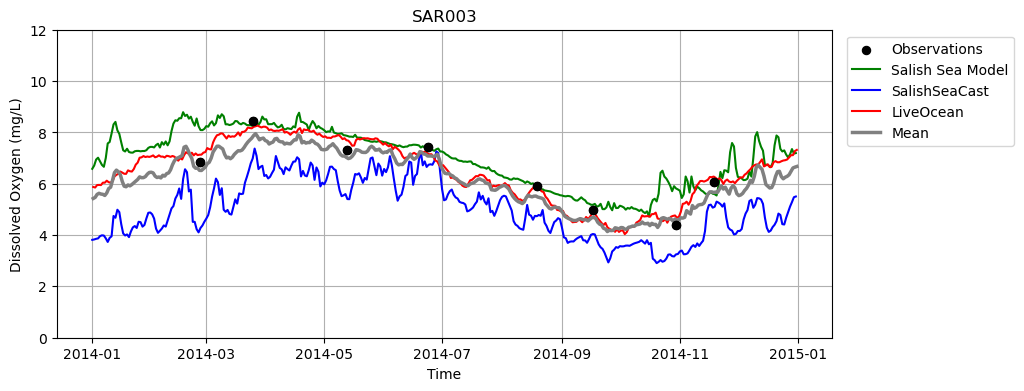

In [74]:
station = "SAR003" #"ADM003"

# Variables
varname_ssc = "dissolved_oxygen"
varname_lo = "oxygen"
varname_obs = "DO"
varname_ssm = "DOXG"

ds_ssc = data_ssc[station]
ds_lo = data_lo[station]
ds_obs = data_obs[data_obs["name"] == station]
ds_ssm = data_ssm[station]

# Target bottom depth
bottom_depth = -30.5

# ------------------------------------------------------------
# Find SSC layer closest to -30.5 m
# ------------------------------------------------------------
ssc_depths = -ds_ssc["deptht"].values
ssc_ind = np.argmin(np.abs(ssc_depths - bottom_depth))

ssc_model_depth = ssc_depths[ssc_ind]
ds_ssc_depth = ds_ssc.isel(deptht=ssc_ind)

# ------------------------------------------------------------
# Find SSM layer closest to -30.5 m
# ------------------------------------------------------------
ssm_depths = ds_ssm["sigma_depth"].mean(dim="time").values
#ssm_ind = np.argmin(np.abs(ssm_depths - bottom_depth))

ssm_ind = 3
ssm_model_depth = ssm_depths[ssm_ind]
ds_ssm_depth = ds_ssm.isel(siglay=ssm_ind)

# ------------------------------------------------------------
# Find LO layer closest to -30.5 m
# ------------------------------------------------------------
lo_depths = ds_lo["z_rho"].mean(dim="ocean_time").values
lo_ind = np.argmin(np.abs(lo_depths - bottom_depth))

lo_model_depth = lo_depths[lo_ind]
ds_lo_depth = ds_lo.isel(s_rho=lo_ind)

# ------------------------------------------------------------
# Convert oxygen to mg/L
# ------------------------------------------------------------
lo_time = ds_lo_depth["ocean_time"].values
lo_do = ds_lo_depth[varname_lo].values * 0.032

ssc_time = ds_ssc_depth["time_counter"].values
ssc_do = ds_ssc_depth[varname_ssc].values * 0.032

ssm_time = ds_ssm_depth["time"].values
ssm_do = ds_ssm_depth[varname_ssm].values
# ------------------------------------------------------------
# Interpolate SSC onto LO time grid
# ------------------------------------------------------------
ssc_do_interp = np.interp(
    lo_time.astype("datetime64[s]").astype("int64"),
    ssc_time.astype("datetime64[s]").astype("int64"),
    ssc_do
)

# Mean of LO and SSC
mean_do = (lo_do + ssc_do_interp + ssm_do) / 3

# ------------------------------------------------------------
# Observations
# ------------------------------------------------------------
ds_obs_depth = ds_obs[np.isclose(ds_obs["z"], bottom_depth)]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 4))

# Observations
plt.scatter(
    ds_obs_depth["time"],
    ds_obs_depth[varname_obs] * 0.032,
    color="black",
    edgecolors="black",
    linewidths=0.8,
    zorder=5,
    #label=f"Obs {abs(bottom_depth):.1f} m"
    label = "Observations"
)

# SSM
plt.plot(
    ssm_time,
    ssm_do,
    color="green",
    linewidth=1.5,
    #label=f"SSM {abs(ssm_model_depth):.1f} m"
    label="Salish Sea Model"
)

# SSC
plt.plot(
    ssc_time,
    ssc_do,
    color="blue",
    linewidth=1.5,
    #label=f"SSC {abs(ssc_model_depth):.1f} m"
    label="SalishSeaCast"
)

# LO
plt.plot(
    lo_time,
    lo_do,
    color="red",
    linewidth=1.5,
    #label=f"LO {abs(lo_model_depth):.1f} m"
    label="LiveOcean"
)

# Mean
plt.plot(
    lo_time,
    mean_do,
    color="grey",
    linewidth=2.5,
    label="Mean"
)

plt.title(f"{station}")
plt.ylim(0, 12)
plt.ylabel("Dissolved Oxygen (mg/L)")
plt.xlabel("Time")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.grid()

plt.show()

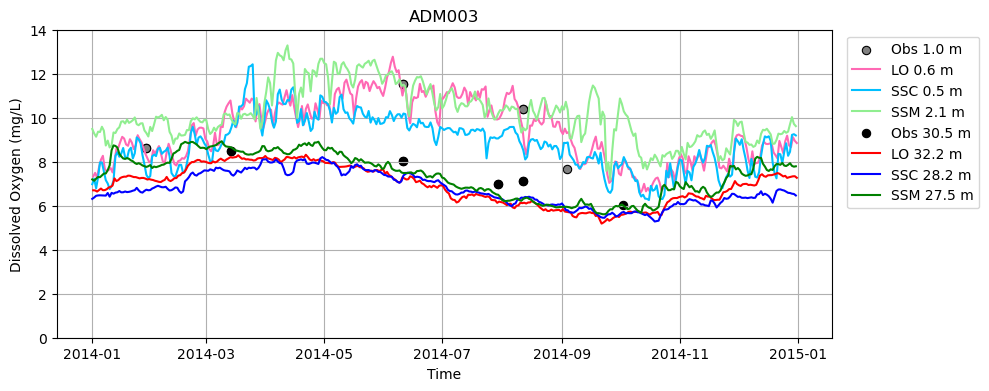

In [66]:
station = "ADM003" 

# variable to plot
varname_ssc = "dissolved_oxygen"
varname_lo = "oxygen"
varname_obs = "DO"
varname_ssm = "DOXG"

ds_ssc = data_ssc[station]
ds_lo = data_lo[station]
ds_obs = data_obs[data_obs["name"] == station]
ds_ssm = data_ssm[station]

surface_depth = -1.0
bottom_depth = -30.5

depth_colors = {
    -1.0: {
        "obs": "gray",
        "lo": "hotpink",
        "ssc": "deepskyblue",
        "ssm": "lightgreen"
    },
    -30.5: {
        "obs": "black",
        "lo": "red",
        "ssc": "blue",
        "ssm": "green"
    }
}

plt.figure(figsize=(10,4))

for obs_depth in [surface_depth, bottom_depth]:
    

    ds_obs_depth = ds_obs[np.isclose(ds_obs["z"], obs_depth)]

    # SSC
    ssc_depths = -ds_ssc["deptht"].values
    ssc_ind = np.argmin(np.abs(ssc_depths - obs_depth))
    ssc_model_depth = ssc_depths[ssc_ind]
    ds_ssc_depth = ds_ssc.isel(deptht=ssc_ind)

    # LO
    lo_depths = ds_lo["z_rho"].mean(dim="ocean_time").values
    lo_ind = np.argmin(np.abs(lo_depths - obs_depth))
    lo_model_depth = lo_depths[lo_ind]
    ds_lo_depth = ds_lo.isel(s_rho=lo_ind)
    
    #SSM
    if obs_depth == surface_depth:
        ssm_ind = 0
    else:
        ssm_ind = 3
    ssm_depths = ds_ssm["sigma_depth"].mean(dim="time").values
    ssm_model_depth = ssm_depths[ssm_ind]

    ds_ssm_depth = ds_ssm.isel(
        siglay=ssm_ind
    )

    plt.scatter(
        ds_obs_depth["time"],
        ds_obs_depth[varname_obs] * 0.032,
        color=depth_colors[obs_depth]["obs"],
        edgecolors="black",   
        linewidths=0.8,       
        label=f"Obs {abs(obs_depth):.1f} m"
    )

    plt.plot(
        ds_lo_depth["ocean_time"],
        ds_lo_depth[varname_lo] * 0.032,
        color=depth_colors[obs_depth]["lo"],
        label=f"LO {abs(lo_model_depth):.1f} m"
    )

    plt.plot(
        ds_ssc_depth["time_counter"],
        ds_ssc_depth[varname_ssc] * 0.032,
        color=depth_colors[obs_depth]["ssc"],
        label=f"SSC {abs(ssc_model_depth):.1f} m"
    )

    plt.plot(
        ds_ssm_depth["time"],
        ds_ssm_depth[varname_ssm],
        color=depth_colors[obs_depth]["ssm"],
        label=f"SSM {abs(ssm_model_depth):.1f} m"
    )

plt.title(
f"{station}")

plt.ylim(0, 14)
plt.ylabel("Dissolved Oxygen (mg/L)")
plt.xlabel("Time")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid()
plt.show()